# Wildfire Prediction Clustering Pipeline
K-Means baseline and GMM main model on meteorological features only. Fire-weather index, occurred, and frp are used only for post-hoc validation. Lat and lon is only used to plot data points onto map.


In [24]:
import os
import warnings

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 150, 'figure.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False})

RANDOM_STATE = 42
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

CLUSTER_FEATURES = [
    'pressure_mean', 'wind_direction_mean', 'wind_direction_std',
    'solar_radiation_mean', 'dewpoint_mean', 'cloud_cover_mean',
    'evapotranspiration_total', 'humidity_min', 'temp_mean',
    'temp_range', 'wind_speed_max'
]
VALIDATION_FEATURES = ['fire_weather_index', 'lat', 'lon', 'occured', 'frp']
geo_colors = ['#2166ac', '#67a9cf', '#fdae61', '#b2182b']
RISK_TIER_NAMES = ['Low', 'Mod', 'High', 'Extreme']


def remap_labels_by_fwi(frame: pd.DataFrame, label_col: str) -> dict:
    means = frame.groupby(label_col)['fire_weather_index'].mean().sort_values()
    return {old_label: new_label for new_label, old_label in enumerate(means.index)}


def boxplot_fwi(frame: pd.DataFrame, label_col: str, title: str, output_name: str) -> None:
    ordered_labels = [0, 1, 2, 3]
    values = [frame.loc[frame[label_col] == label, 'fire_weather_index'].to_numpy() for label in ordered_labels]

    fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot(values, labels=RISK_TIER_NAMES, patch_artist=True, showfliers=False)
    box_colors = ['#dbe9f6', '#a6bddb', '#fdcc8a', '#e34a33']

    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')

    for artist_group in ['whiskers', 'caps', 'medians']:
        for artist in bp[artist_group]:
            artist.set_color('black')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Risk tier')
    ax.set_ylabel('fire_weather_index')
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, output_name), bbox_inches='tight', dpi=200)
    plt.show()
    plt.close(fig)


def plot_geo(frame: pd.DataFrame, title: str, output_name: str, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> None:
    fig, ax = plt.subplots(figsize=(18, 9) if 'Global' in title else (8, 10))
    for label, color in enumerate(geo_colors):
        subset = frame[frame['gmm_label'] == label]
        if subset.empty:
            continue
        ax.scatter(
            subset['lon'],
            subset['lat'],
            s=3 if 'Global' in title else 8,
            alpha=0.45 if 'Global' in title else 0.55,
            color=color,
            linewidths=0,
            label=f'{RISK_TIER_NAMES[label]} (n={len(subset):,})'
        )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.grid(True, alpha=0.2 if 'Global' in title else 0.25)
    ax.legend(title='Risk tier', markerscale=4 if 'Global' in title else 3, framealpha=0.9)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, output_name), bbox_inches='tight', dpi=200)
    plt.show()
    plt.close(fig)


data_path = kagglehub.dataset_download('vijayaragulvr/wildfire-prediction')
DATA_PATH = os.path.join(data_path, 'final_dataset.csv')
df = pd.read_csv(DATA_PATH)

X_clust = df[CLUSTER_FEATURES].copy()
X_val = df[VALIDATION_FEATURES].copy()

print('Dataset shape:', df.shape)
print('X_clust shape:', X_clust.shape)
print('X_val shape:', X_val.shape)
print('Validation columns held out from fitting:', list(X_val.columns))

scaler = StandardScaler()
X_arr = scaler.fit_transform(X_clust)
joblib.dump(scaler, 'scaler.pkl')
print('Saved scaler -> scaler.pkl')


Dataset shape: (118858, 17)
X_clust shape: (118858, 11)
X_val shape: (118858, 5)
Validation columns held out from fitting: ['fire_weather_index', 'lat', 'lon', 'occured', 'frp']
Saved scaler -> scaler.pkl


K-Means silhouette_score (K=4): 0.1368
K-Means mean fire_weather_index by cluster:


,mean_fire_weather_index
kmeans_label,
0,5.745338
1,11.696377
2,13.103220
3,32.889401


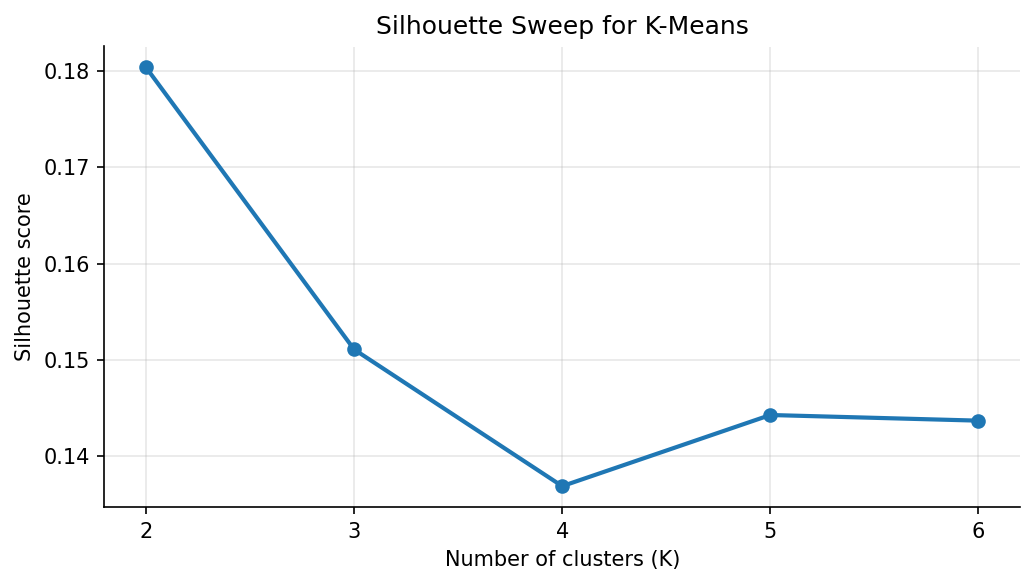

Saved model -> kmeans_model.pkl


In [25]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
kmeans_raw = kmeans.fit_predict(X_arr)
kmeans_map = remap_labels_by_fwi(df.assign(kmeans_label=kmeans_raw), 'kmeans_label')
df['kmeans_label'] = pd.Series(kmeans_raw, index=df.index).map(kmeans_map).astype(int)
kmeans_means = df.groupby('kmeans_label')['fire_weather_index'].mean().sort_index()
kmeans_silhouette = silhouette_score(X_arr, df['kmeans_label'], sample_size=min(10000, len(df)), random_state=RANDOM_STATE)

print(f'K-Means silhouette_score (K=4): {kmeans_silhouette:.4f}')
print('K-Means mean fire_weather_index by cluster:')
display(kmeans_means.rename('mean_fire_weather_index').to_frame())

k_values = [2, 3, 4, 5, 6]
sil_scores = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_arr)
    sil_scores.append(silhouette_score(X_arr, labels, sample_size=min(10000, len(df)), random_state=RANDOM_STATE))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, sil_scores, marker='o', linewidth=2, color='#1f77b4')
ax.set_xticks(k_values)
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette Sweep for K-Means')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'silhouette_sweep.png'), bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

joblib.dump(kmeans, 'kmeans_model.pkl')
print('Saved model -> kmeans_model.pkl')


GMM BIC (K=4): 2545082.4365
GMM AIC (K=4): 2542070.1885
GMM mean fire_weather_index by cluster:


,mean_fire_weather_index
gmm_label,
0,7.094971
1,7.210760
2,15.198537
3,34.116094


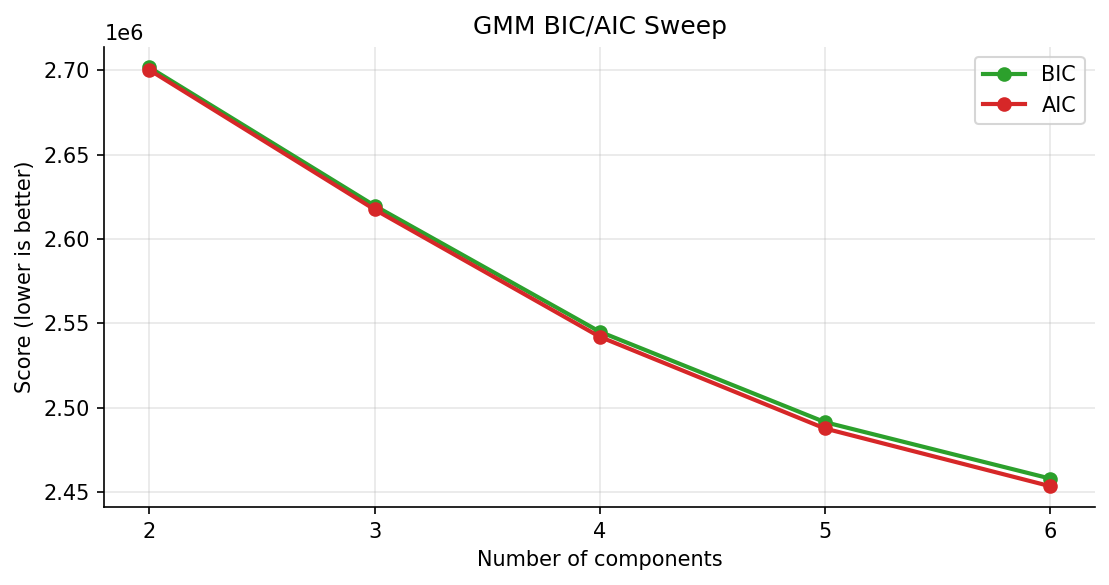

Saved model -> gmm_model.pkl
Saved probabilities -> gmm_proba.npy


In [26]:
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=RANDOM_STATE)
gmm.fit(X_arr)
gmm_raw = gmm.predict(X_arr)
gmm_proba = gmm.predict_proba(X_arr)
gmm_map = remap_labels_by_fwi(df.assign(gmm_label=gmm_raw), 'gmm_label')
df['gmm_label'] = pd.Series(gmm_raw, index=df.index).map(gmm_map).astype(int)
gmm_means = df.groupby('gmm_label')['fire_weather_index'].mean().sort_index()
gmm_bic = gmm.bic(X_arr)
gmm_aic = gmm.aic(X_arr)

print(f'GMM BIC (K=4): {gmm_bic:.4f}')
print(f'GMM AIC (K=4): {gmm_aic:.4f}')
print('GMM mean fire_weather_index by cluster:')
display(gmm_means.rename('mean_fire_weather_index').to_frame())

bic_scores = []
aic_scores = []
for k in k_values:
    model = GaussianMixture(n_components=k, covariance_type='full', random_state=RANDOM_STATE)
    model.fit(X_arr)
    bic_scores.append(model.bic(X_arr))
    aic_scores.append(model.aic(X_arr))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(k_values, bic_scores, marker='o', linewidth=2, color='#2ca02c', label='BIC')
ax.plot(k_values, aic_scores, marker='o', linewidth=2, color='#d62728', label='AIC')
ax.set_xticks(k_values)
ax.set_xlabel('Number of components')
ax.set_ylabel('Score (lower is better)')
ax.set_title('GMM BIC/AIC Sweep')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'bic_aic_sweep.png'), bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

joblib.dump(gmm, 'gmm_model.pkl')
np.save('gmm_proba.npy', gmm_proba)
print('Saved model -> gmm_model.pkl')
print('Saved probabilities -> gmm_proba.npy')


=== KMeans mean fire_weather_index by cluster ===


,mean_fire_weather_index
kmeans_label,
0,5.745338
1,11.696377
2,13.103220
3,32.889401


Spearman correlation between cluster rank and mean FWI: 1.0000


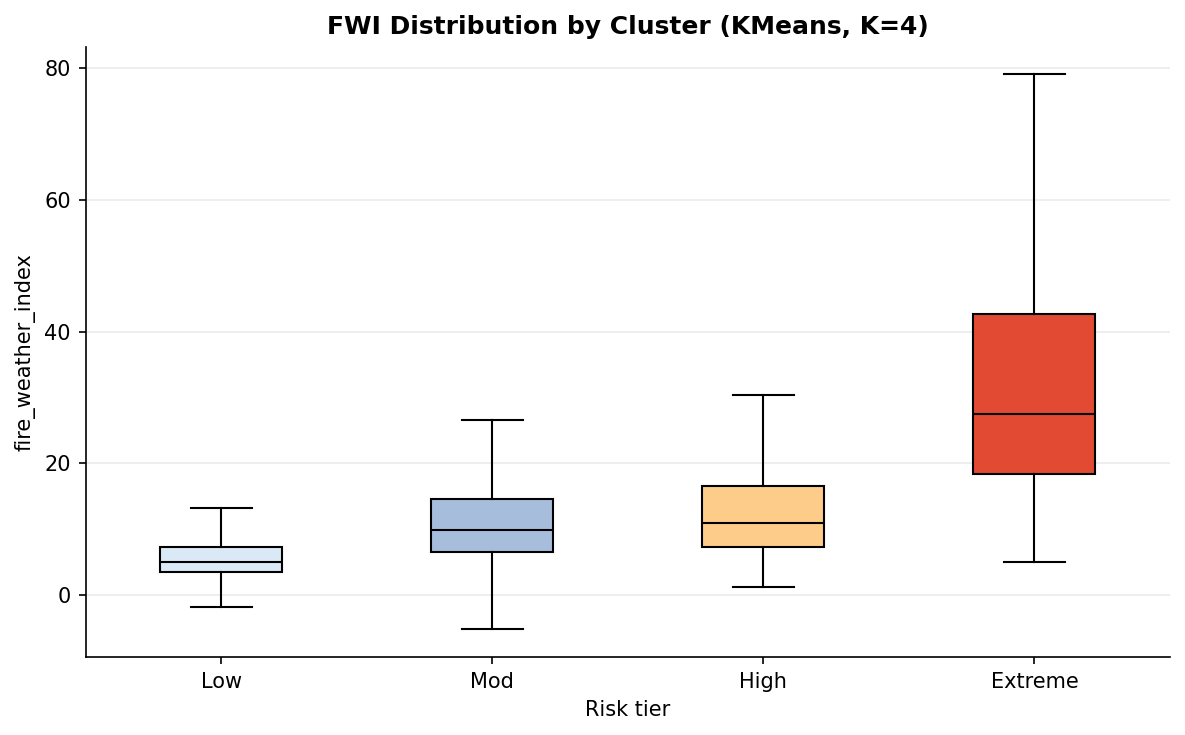

=== GMM mean fire_weather_index by cluster ===


,mean_fire_weather_index
gmm_label,
0,7.094971
1,7.210760
2,15.198537
3,34.116094


Spearman correlation between cluster rank and mean FWI: 1.0000


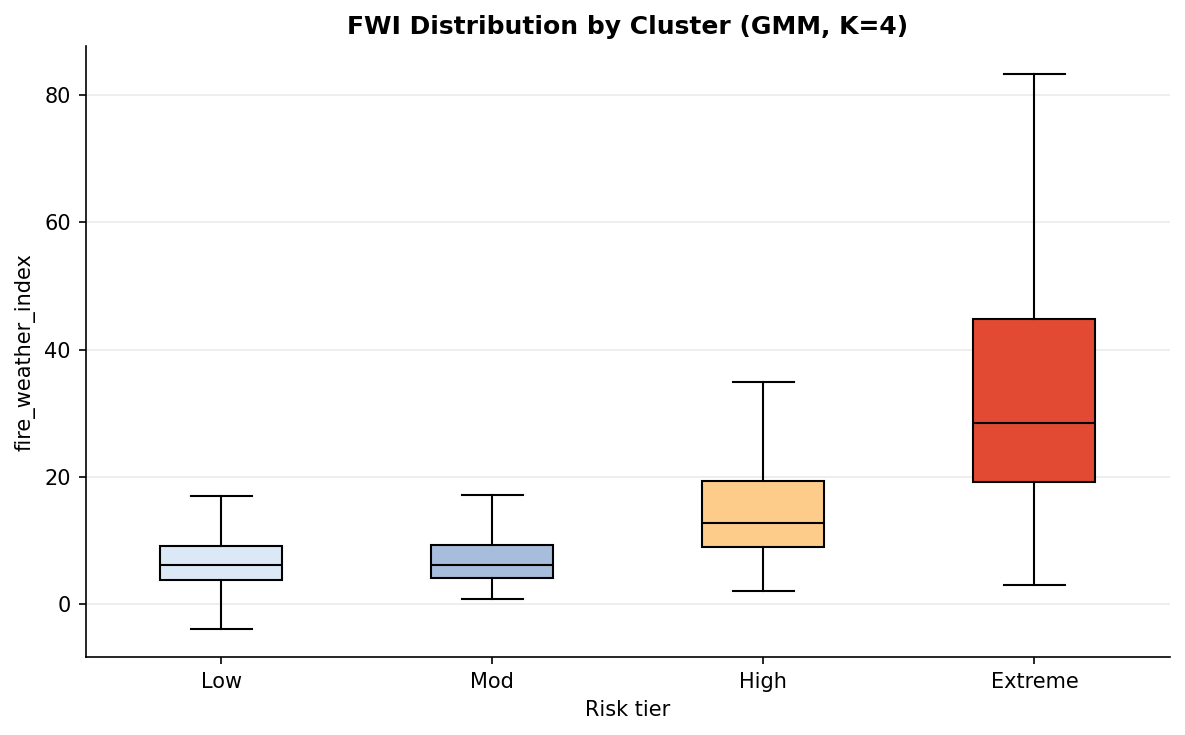

,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,evapotranspiration_total,humidity_min,temp_mean,temp_range,wind_speed_max
gmm_label,,,,,,,,,,,
0,942.303605,177.852507,55.659227,246.295158,7.544694,32.307067,4.645942,30.939104,18.158477,12.928748,17.298304
1,980.088956,154.268346,62.173245,253.332738,18.379276,41.774625,5.341807,37.347410,26.897465,11.993757,14.997940
2,921.358608,122.470973,55.166166,251.401004,5.569059,28.373498,6.093579,17.157801,25.142076,15.273356,14.622597
3,960.980085,153.201954,68.689040,285.701830,3.748207,28.068902,8.236341,12.816817,28.733723,14.957837,21.886765


,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,evapotranspiration_total,humidity_min,temp_mean,temp_range,wind_speed_max
kmeans_label,,,,,,,,,,,
0,974.989624,164.344779,55.625452,234.806474,16.167718,46.986689,4.691758,40.795069,23.896834,10.976445,15.236876
1,902.361405,147.843895,41.484066,252.052499,3.602737,18.810862,5.389280,20.368445,20.052551,15.101640,16.158855
2,956.844206,163.982927,101.823536,258.789956,9.765947,35.757493,6.078597,19.656004,27.177852,14.913150,14.193582
3,962.492683,112.302270,38.048669,291.475196,5.070532,27.507457,8.268536,14.478893,28.412542,14.786739,22.285654


,fire_occurrence_rate,mean_frp_given_fire
gmm_label,,
0,0.474093,22.086682
1,0.432073,15.160224
2,0.523614,17.128164
3,0.586812,21.868816


,size,fire_rate,median_frp,zone_multiplier
cluster_label,,,,
0,28294,0.474093,9.57,1.11
1,29907,0.432073,8.64,1.00
2,39214,0.523614,9.84,1.14
3,21443,0.586812,11.11,1.29


Saved outputs:
  scaler.pkl
  kmeans_model.pkl
  gmm_model.pkl
  gmm_proba.npy
  df_with_labels.csv
  figures/cluster_profile_gmm.csv
  figures/cluster_profile_kmeans.csv
  figures/fire_occurrence_frp_by_gmm.csv
  figures/cluster_summary_gmm.csv


In [27]:
# Consolidated post-model analysis and exports
os.makedirs(FIGURES_DIR, exist_ok=True)

for label_col, model_name in [('kmeans_label', 'KMeans'), ('gmm_label', 'GMM')]:
    table = df.groupby(label_col)['fire_weather_index'].mean().sort_index().to_frame('mean_fire_weather_index')
    spearman_corr = spearmanr(table.index.to_numpy(), table['mean_fire_weather_index'].to_numpy()).statistic

    print(f'=== {model_name} mean fire_weather_index by cluster ===')
    display(table)
    print(f'Spearman correlation between cluster rank and mean FWI: {spearman_corr:.4f}')

    boxplot_fwi(
        df,
        label_col,
        f'FWI Distribution by Cluster ({model_name}, K=4)',
        f'fwi_boxplot_{model_name.lower()}.png'
    )

cluster_profile_gmm = df.groupby('gmm_label')[CLUSTER_FEATURES].mean().sort_index()
cluster_profile_kmeans = df.groupby('kmeans_label')[CLUSTER_FEATURES].mean().sort_index()

fire_table = df.groupby('gmm_label').agg(
    fire_occurrence_rate=('occured', 'mean'),
    mean_frp_given_fire=('frp', lambda s: s[s > 0].mean())
).sort_index()

cluster_summary = df.groupby('gmm_label').agg(
    size=('gmm_label', 'count'),
    fire_rate=('occured', 'mean'),
    median_frp=('frp', lambda s: s[s > 0].median())
).sort_index()
min_med_frp = cluster_summary['median_frp'].min()
cluster_summary['zone_multiplier'] = (cluster_summary['median_frp'] / min_med_frp).round(2)
cluster_summary.index.name = 'cluster_label'

display(cluster_profile_gmm)
display(cluster_profile_kmeans)
display(fire_table)
display(cluster_summary)

cluster_profile_gmm.to_csv(os.path.join(FIGURES_DIR, 'cluster_profile_gmm.csv'))
cluster_profile_kmeans.to_csv(os.path.join(FIGURES_DIR, 'cluster_profile_kmeans.csv'))
fire_table.to_csv(os.path.join(FIGURES_DIR, 'fire_occurrence_frp_by_gmm.csv'))
cluster_summary.to_csv(os.path.join(FIGURES_DIR, 'cluster_summary_gmm.csv'))
df.to_csv('df_with_labels.csv', index=False)

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(gmm, 'gmm_model.pkl')
np.save('gmm_proba.npy', gmm_proba)

print('Saved outputs:')
print('  scaler.pkl')
print('  kmeans_model.pkl')
print('  gmm_model.pkl')
print('  gmm_proba.npy')
print('  df_with_labels.csv')
print(f"  {os.path.join(FIGURES_DIR, 'cluster_profile_gmm.csv')}")
print(f"  {os.path.join(FIGURES_DIR, 'cluster_profile_kmeans.csv')}")
print(f"  {os.path.join(FIGURES_DIR, 'fire_occurrence_frp_by_gmm.csv')}")
print(f"  {os.path.join(FIGURES_DIR, 'cluster_summary_gmm.csv')}")

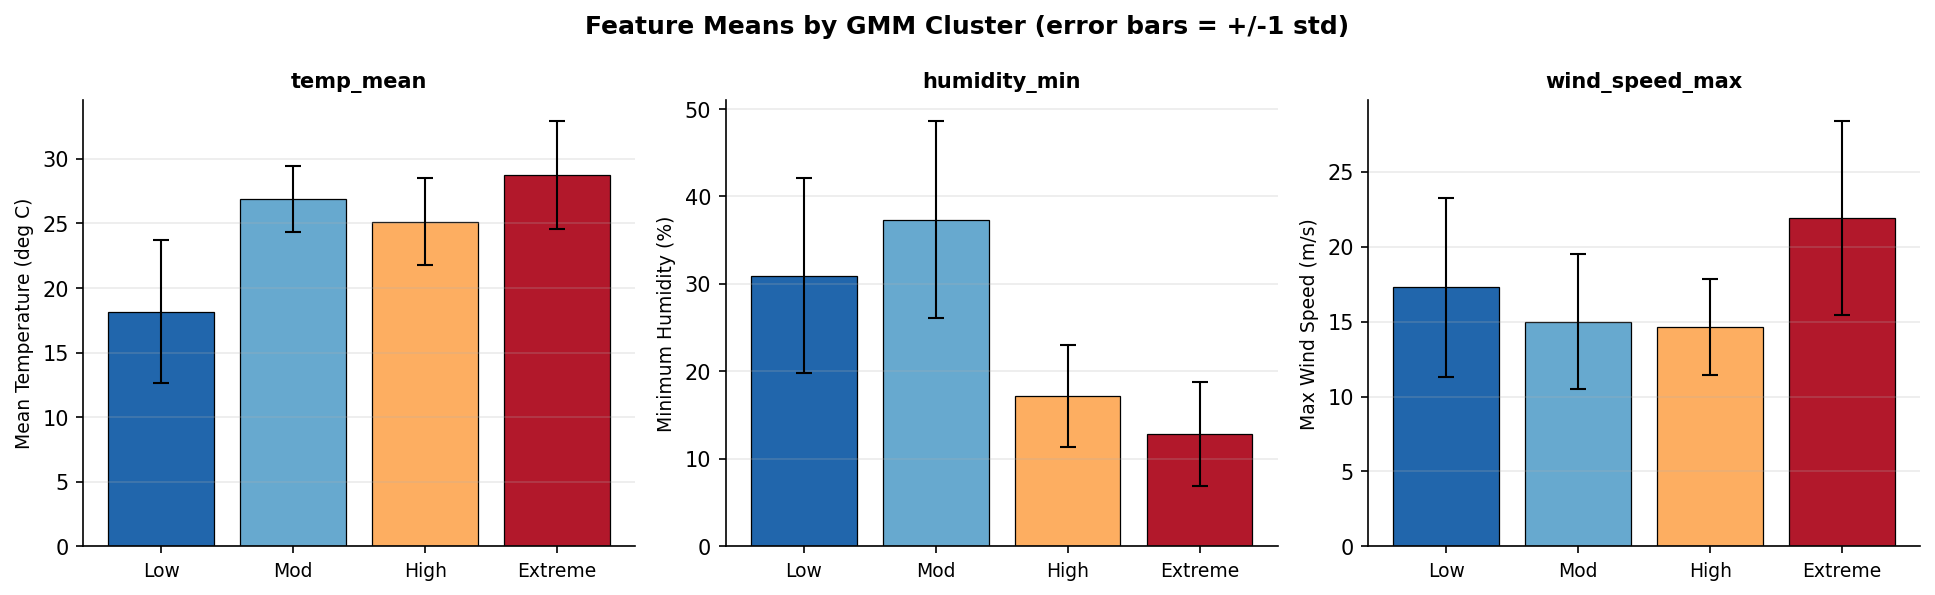

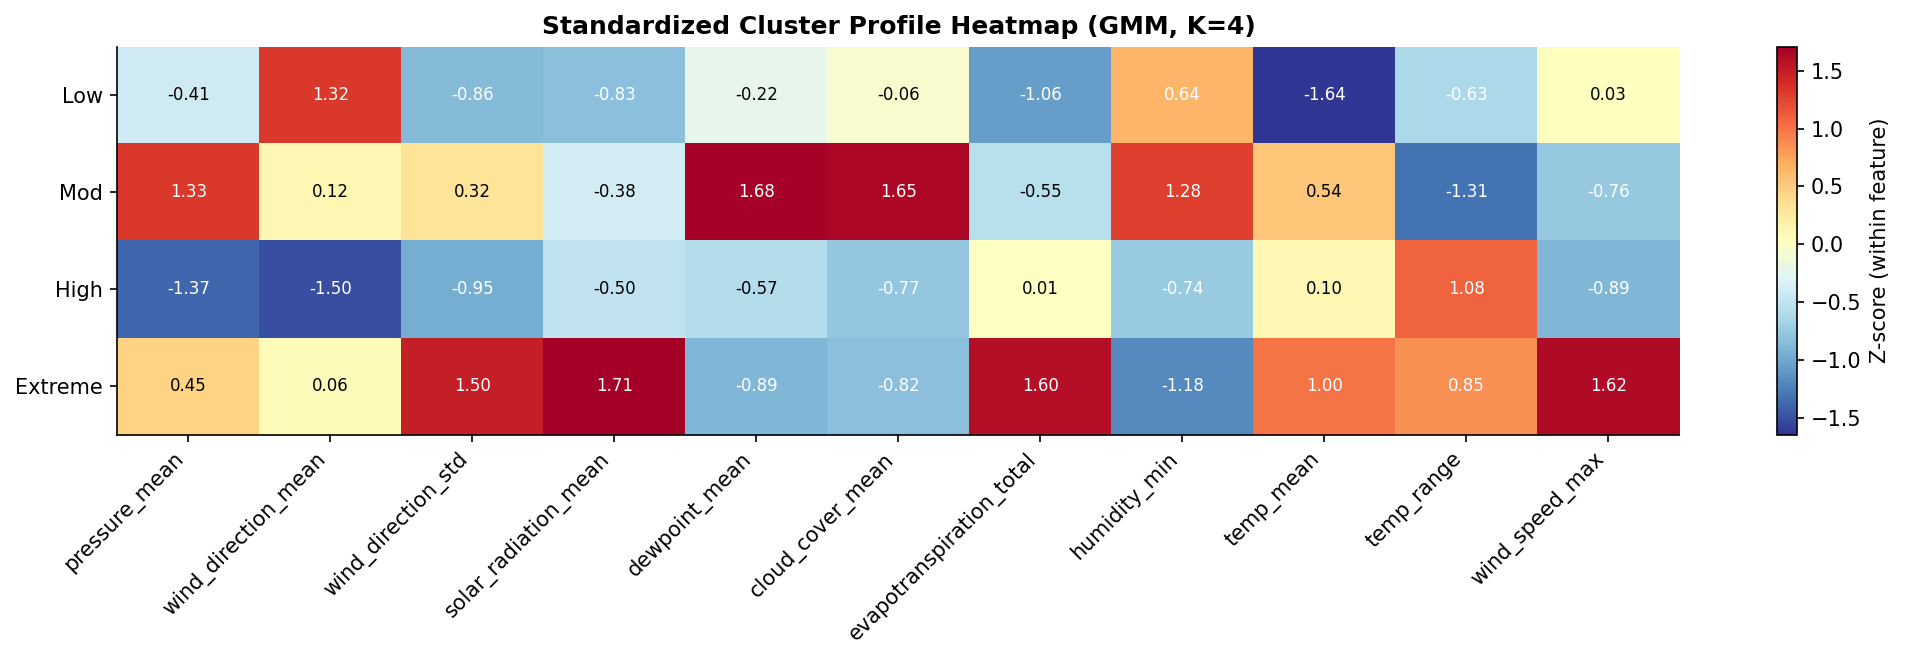

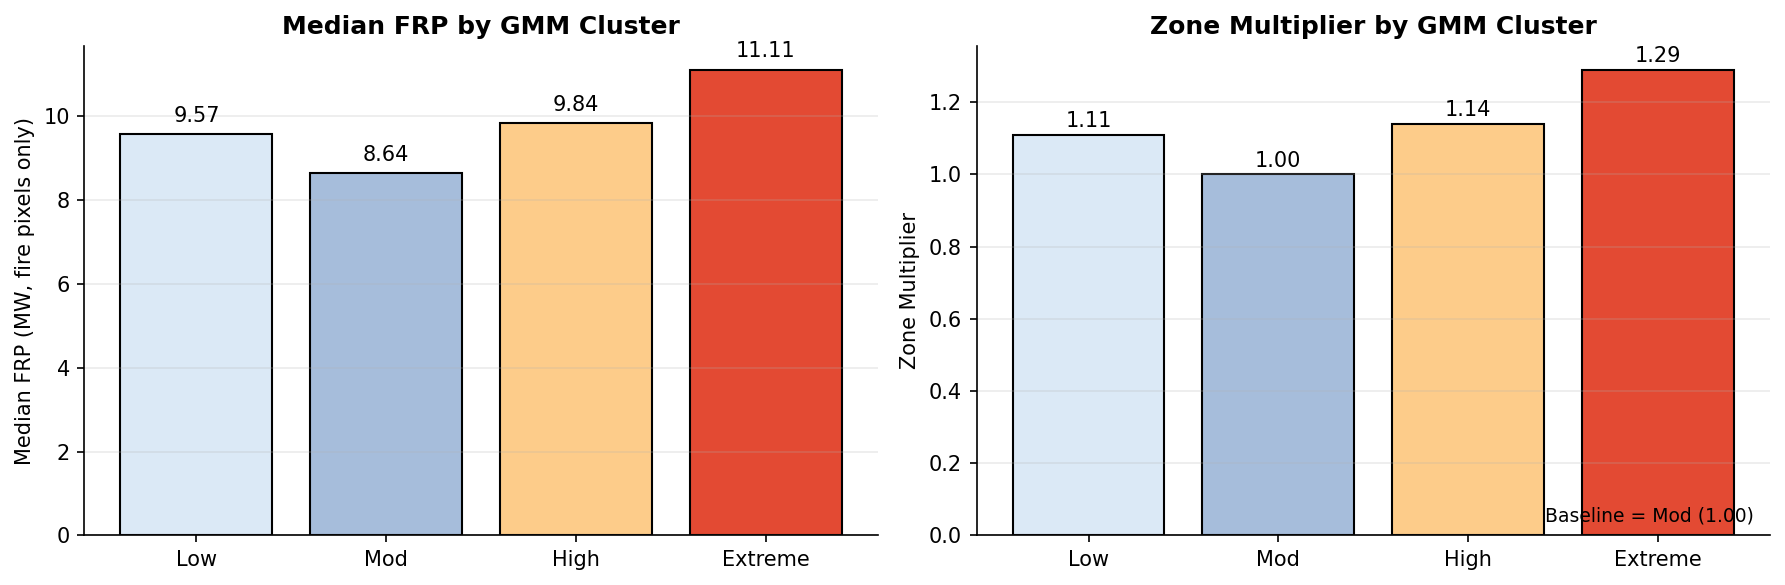

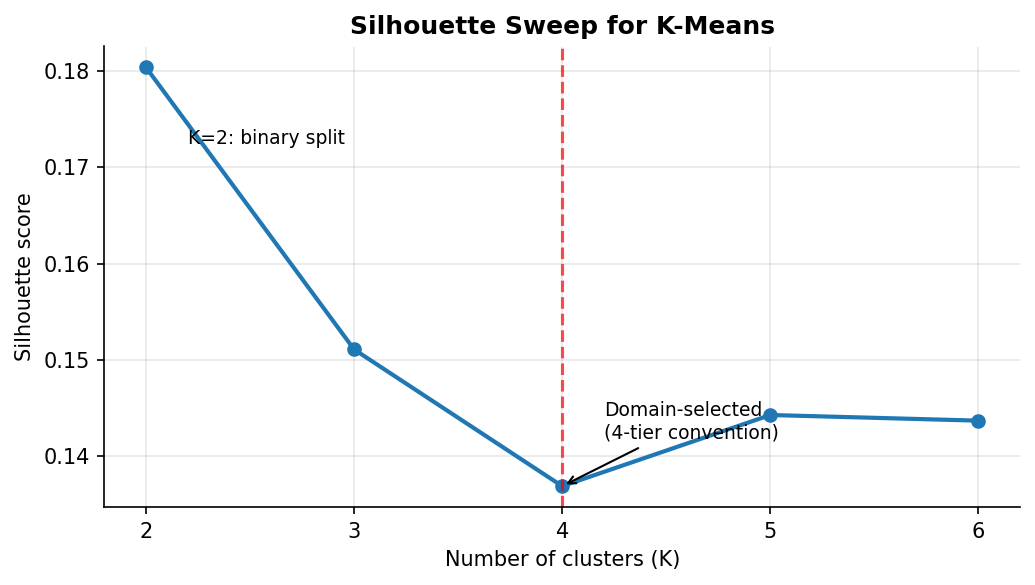

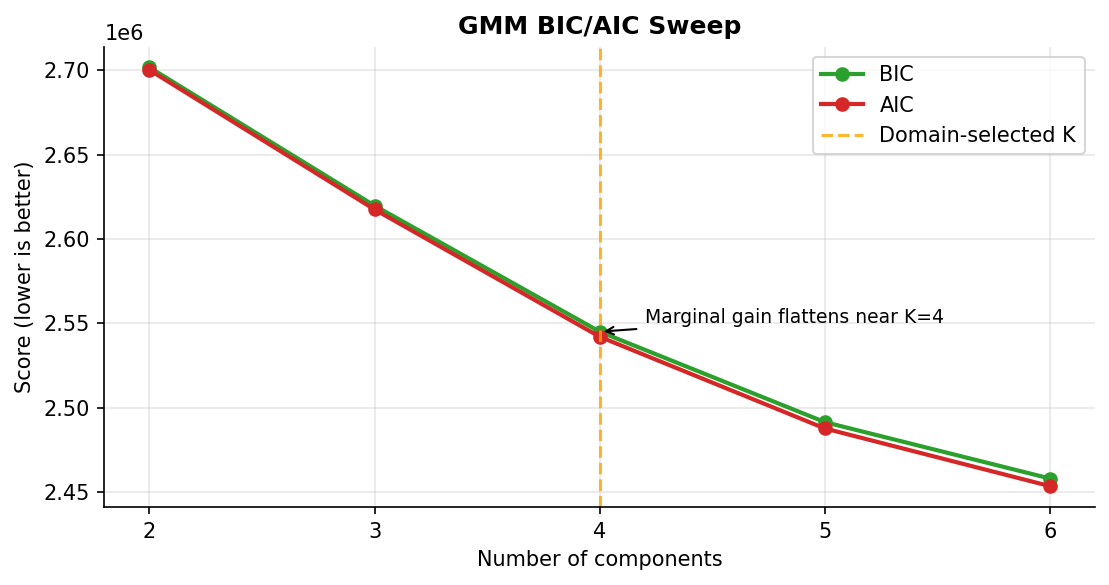

In [28]:
# Consolidated visualization suite
from sklearn.decomposition import PCA

_TIER_XTICKLABELS = ['Low', 'Mod', 'High', 'Extreme']
_CLUSTER_COLORS = ['#2166ac', '#67a9cf', '#fdae61', '#b2182b']
_BAR_COLORS = ['#dbe9f6', '#a6bddb', '#fdcc8a', '#e34a33']
_CLUSTER_LABELS = [0, 1, 2, 3]

# Feature means by cluster (selected variables)
_PANEL_FEATURES = [
    ('temp_mean', 'Mean Temperature (deg C)'),
    ('humidity_min', 'Minimum Humidity (%)'),
    ('wind_speed_max', 'Max Wind Speed (m/s)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (feat, ylabel) in zip(axes, _PANEL_FEATURES):
    means = df.groupby('gmm_label')[feat].mean()
    stds = df.groupby('gmm_label')[feat].std()
    ax.bar(
        _CLUSTER_LABELS,
        means,
        yerr=stds,
        color=_CLUSTER_COLORS,
        edgecolor='black',
        linewidth=0.6,
        capsize=4,
        error_kw={'linewidth': 1}
    )
    ax.set_xticks(_CLUSTER_LABELS)
    ax.set_xticklabels(_TIER_XTICKLABELS, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.grid(True, axis='y', alpha=0.25)

fig.suptitle('Feature Means by GMM Cluster (error bars = +/-1 std)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_feature_means_3panel.png'), bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

# Standardized heatmap (GMM profile)
gmm_profile_z = (cluster_profile_gmm - cluster_profile_gmm.mean(axis=0)) / cluster_profile_gmm.std(axis=0, ddof=0)
fig, ax = plt.subplots(figsize=(14, 4.5))
img = ax.imshow(gmm_profile_z.to_numpy(), cmap='RdYlBu_r', aspect='auto')
for row_idx in range(gmm_profile_z.shape[0]):
    for col_idx in range(gmm_profile_z.shape[1]):
        value = gmm_profile_z.iloc[row_idx, col_idx]
        text_color = 'white' if abs(value) >= 0.6 else 'black'
        ax.text(col_idx, row_idx, f'{value:.2f}', ha='center', va='center', fontsize=8, color=text_color)
ax.set_xticks(np.arange(len(CLUSTER_FEATURES)))
ax.set_xticklabels(CLUSTER_FEATURES, rotation=45, ha='right')
ax.set_yticks(np.arange(len(gmm_profile_z.index)))
ax.set_yticklabels([RISK_TIER_NAMES[int(k)] for k in gmm_profile_z.index])
ax.set_title('Standardized Cluster Profile Heatmap (GMM, K=4)', fontweight='bold')
cb = fig.colorbar(img, ax=ax)
cb.set_label('Z-score (within feature)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cluster_profile_heatmap_gmm_zscore.png'), bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

# FRP and zone multiplier
_baseline_idx = int(cluster_summary['median_frp'].idxmin())
_tier_names = ['Low', 'Mod', 'High', 'Extreme']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(_CLUSTER_LABELS, cluster_summary['median_frp'], color=_BAR_COLORS, edgecolor='black')
for i, value in enumerate(cluster_summary['median_frp']):
    axes[0].annotate(f'{value:.2f}', xy=(i, value), xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10)
axes[0].set_xticks(_CLUSTER_LABELS)
axes[0].set_xticklabels(_TIER_XTICKLABELS)
axes[0].set_ylabel('Median FRP (MW, fire pixels only)')
axes[0].set_title('Median FRP by GMM Cluster', fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.25)

axes[1].bar(_CLUSTER_LABELS, cluster_summary['zone_multiplier'], color=_BAR_COLORS, edgecolor='black')
for i, zm in enumerate(cluster_summary['zone_multiplier']):
    axes[1].text(i, zm + 0.01, f'{zm:.2f}', ha='center', va='bottom', fontsize=10)
axes[1].set_xticks(_CLUSTER_LABELS)
axes[1].set_xticklabels(_TIER_XTICKLABELS)
axes[1].set_ylabel('Zone Multiplier')
axes[1].set_title('Zone Multiplier by GMM Cluster', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.25)
axes[1].text(
    0.98,
    0.02,
    f"Baseline = {_tier_names[_baseline_idx]} (1.00)",
    transform=axes[1].transAxes,
    ha='right',
    va='bottom',
    fontsize=9
 )

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_frp_zonemult.png'), bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

# Silhouette and BIC/AIC with K=4 annotations
_score_at_k4 = sil_scores[k_values.index(4)]
_score_at_k2 = sil_scores[k_values.index(2)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, sil_scores, marker='o', linewidth=2, color='#1f77b4')
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7)
ax.annotate('Domain-selected\n(4-tier convention)', xy=(4, _score_at_k4), xytext=(4.2, _score_at_k4 + 0.005), arrowprops=dict(arrowstyle='->'), fontsize=9)
ax.annotate('K=2: binary split', xy=(2, _score_at_k2), xytext=(2.2, _score_at_k2 - 0.008), fontsize=9)
ax.set_xticks(k_values)
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette Sweep for K-Means', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_silhouette_annotated.png'), bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)

_bic_at_k4 = bic_scores[k_values.index(4)]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(k_values, bic_scores, marker='o', linewidth=2, color='#2ca02c', label='BIC')
ax.plot(k_values, aic_scores, marker='o', linewidth=2, color='#d62728', label='AIC')
ax.axvline(x=4, color='orange', linestyle='--', alpha=0.8, label='Domain-selected K')
ax.annotate('Marginal gain flattens near K=4', xy=(4, _bic_at_k4), xytext=(4.2, _bic_at_k4 + 5000), arrowprops=dict(arrowstyle='->'), fontsize=9)
ax.set_xticks(k_values)
ax.set_xlabel('Number of components')
ax.set_ylabel('Score (lower is better)')
ax.set_title('GMM BIC/AIC Sweep', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_bic_aic_annotated.png'), bbox_inches='tight', dpi=200)
plt.show()
plt.close(fig)


### K=4 Model Selection Justification

We choose **K=4** primarily by domain convention: wildfire danger communication is commonly framed as a four-tier risk scale (very low, low, moderate, high).

The monotonic decrease in GMM **BIC/AIC** with larger K is expected for meteorological data with continuous gradients, where additional components keep fitting finer structure.

The relatively low silhouette values are also expected for this feature space because environmental transitions are gradual rather than sharply separated; therefore, silhouette is informative but not the sole decision criterion.

### Spearman Rho Interpretation Note

The observed Spearman \(\rho = 1.0\) here is guaranteed by construction of `remap_labels_by_fwi`, which explicitly reorders cluster labels by ascending mean FWI.

Interpret this as a **sanity check that remapping worked as intended**, not as independent external validation of clustering quality.

Using cluster column: gmm_label

Cluster distribution (count and %):
         count  percentage
cluster                   
0        28294       23.80
1        29907       25.16
2        39214       32.99
3        21443       18.04


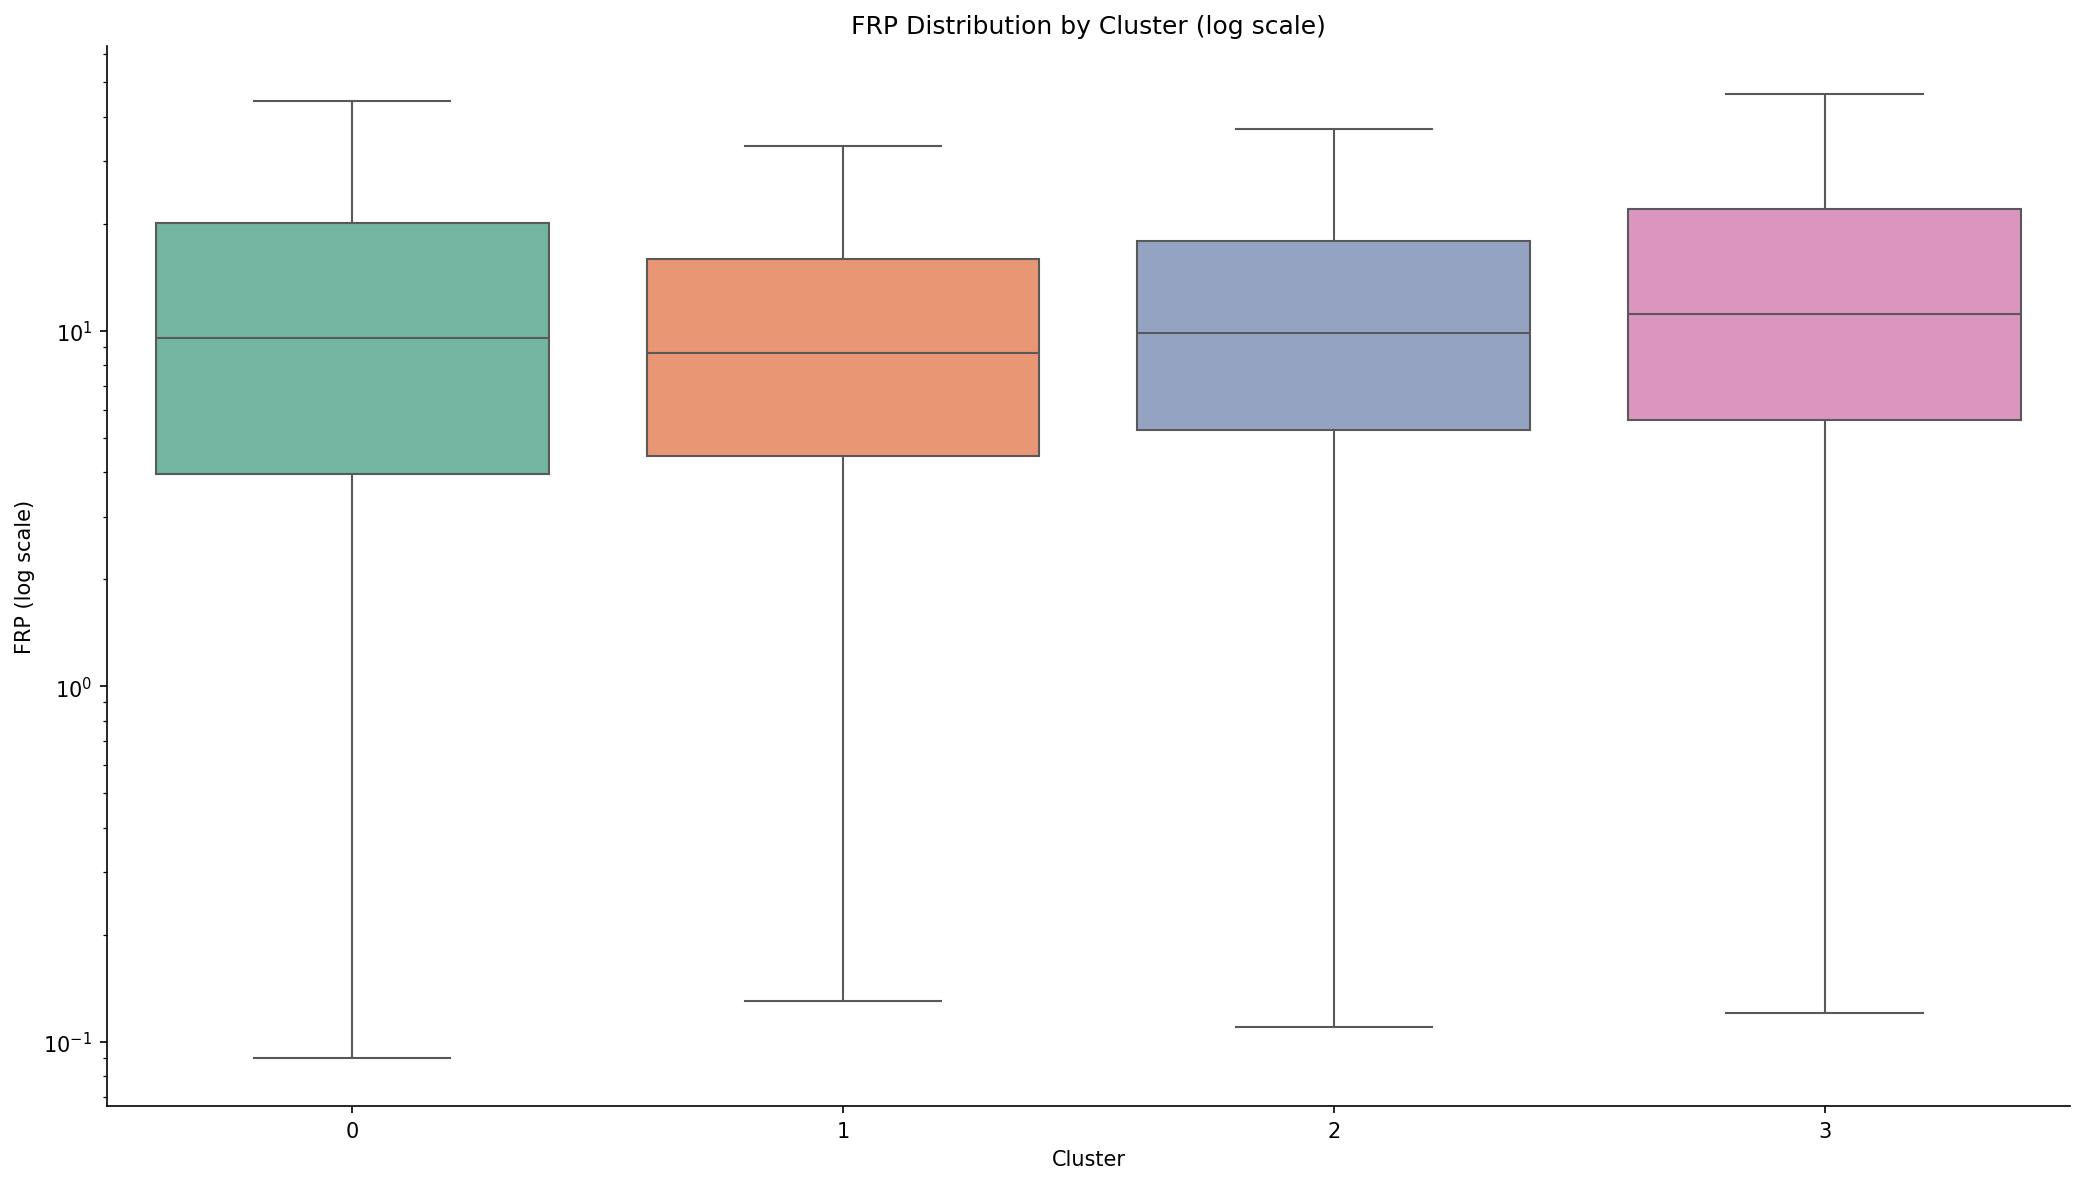

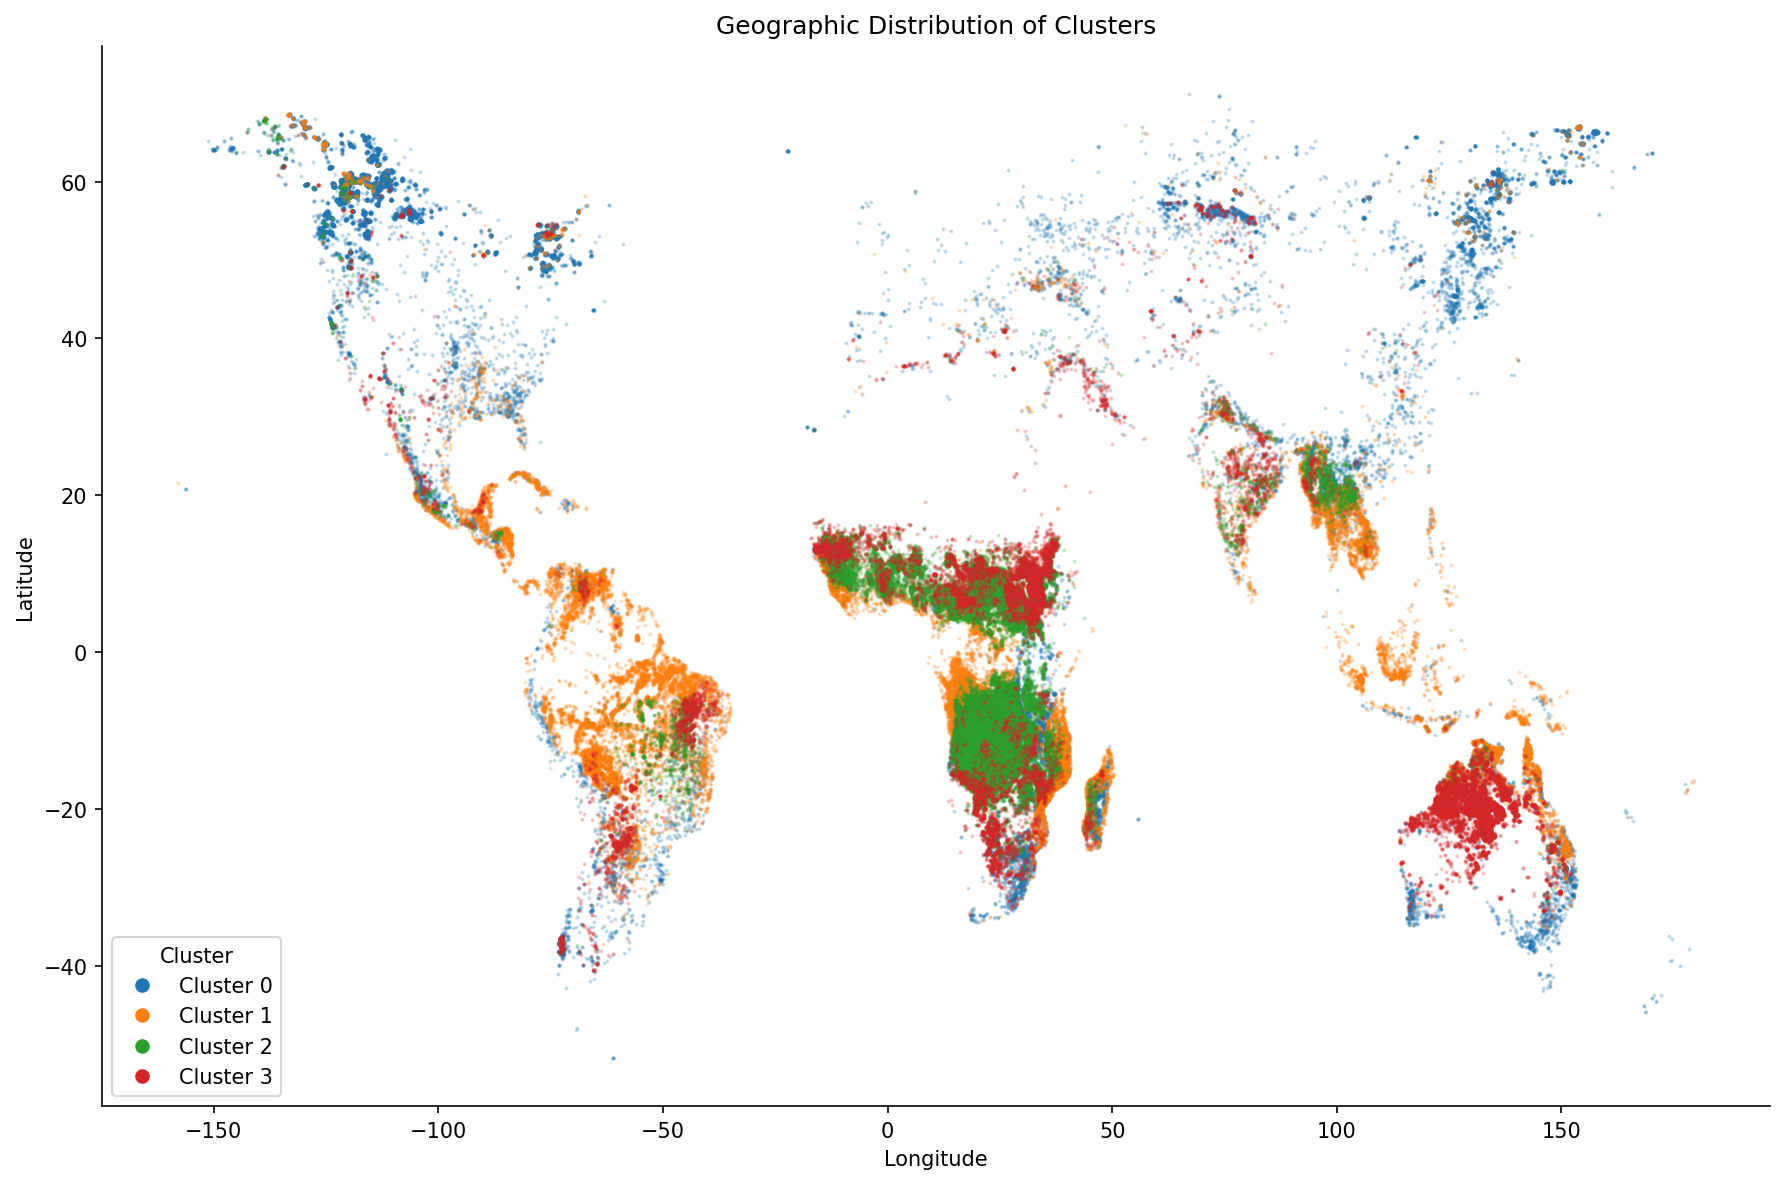

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# --- Resolve cluster label column from previous cells ---
cluster_candidates = ["cluster", "gmm_label", "kmeans_label"]
cluster_col = next((c for c in cluster_candidates if c in df.columns), None)
if cluster_col is None:
    raise ValueError(
        "No cluster label column found. Expected one of: "
        f"{cluster_candidates}. Available columns include: {list(df.columns)[:20]}..."
    )
print(f"Using cluster column: {cluster_col}")

# --- Validate required columns ---
required_cols = ["frp", "lat", "lon", "occured", cluster_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Work on a clean subset to avoid NaN issues in plots
invest_df = df[required_cols].copy()
invest_df = invest_df.rename(columns={cluster_col: "cluster"})
invest_df = invest_df.dropna(subset=["frp", "lat", "lon", "cluster"])

# Ensure numeric/dtype consistency
invest_df["cluster"] = pd.to_numeric(invest_df["cluster"], errors="coerce")
invest_df = invest_df.dropna(subset=["cluster"])
invest_df["cluster"] = invest_df["cluster"].astype(int)

# Restrict to expected cluster labels
cluster_order = [0, 1, 2, 3]
invest_df = invest_df[invest_df["cluster"].isin(cluster_order)]

# 1) Cluster Distribution (absolute counts + percentages)
cluster_counts = invest_df["cluster"].value_counts().reindex(cluster_order, fill_value=0)
cluster_pct = (cluster_counts / cluster_counts.sum() * 100).round(2)
cluster_distribution = pd.DataFrame(
    {
        "count": cluster_counts,
        "percentage": cluster_pct,
    }
)
print("\nCluster distribution (count and %):")
print(cluster_distribution)

# 2) Outlier Investigation (FRP distributions by cluster)
# Filter FRP <= 0 so the log y-axis is valid and spread is visible.
plot_df = invest_df[invest_df["frp"] > 0].copy()

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=plot_df,
    x="cluster",
    y="frp",
    order=cluster_order,
    palette="Set2",
    showfliers=False,
)
plt.yscale("log")
plt.title("FRP Distribution by Cluster (log scale)")
plt.xlabel("Cluster")
plt.ylabel("FRP (log scale)")
plt.tight_layout()
plt.show()

# 3) Geographic Context (lon-lat scatter, colored by cluster)
colors = sns.color_palette("tab10", n_colors=len(cluster_order))
color_map = dict(zip(cluster_order, colors))

fig, ax = plt.subplots(figsize=(12, 8))
for c in cluster_order:
    grp = invest_df[invest_df["cluster"] == c]
    ax.scatter(
        grp["lon"],
        grp["lat"],
        s=1,
        alpha=0.2,
        color=color_map[c],
        label=f"Cluster {c}",
    )

ax.set_title("Geographic Distribution of Clusters")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", label=f"Cluster {c}", markerfacecolor=color_map[c], markersize=8)
    for c in cluster_order
]
ax.legend(handles=legend_handles, title="Cluster", loc="best")
plt.tight_layout()
plt.show()